## Install Packages

In [7]:
!pip install contextily

  Using cached contextily-1.7.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mercantile-1.2.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)
  Using cached affine-2.4.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
Using cached contextily-1.7.0-py3-none-any.whl (16 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.1-py3-none-any.whl (40 kB)
Using cached mercantile-1.2.1-py3-none-any.whl (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 18.2 MB/s  0:00:01m0:00:0100:01
Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
Using cached affine-2.4.0-py3-none-any.whl (15 kB)
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [contex

In [8]:
# packages
# Removed google.colab import as it is not needed in a local Jupyter Notebook
import io
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import seaborn as sns
import contextily as ctx
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches

## Upload Clean Crash Dataset

In [9]:
crash_df = pd.read_csv('../clean_datasets/crash_df_3_8.csv')

## Create HeatMap

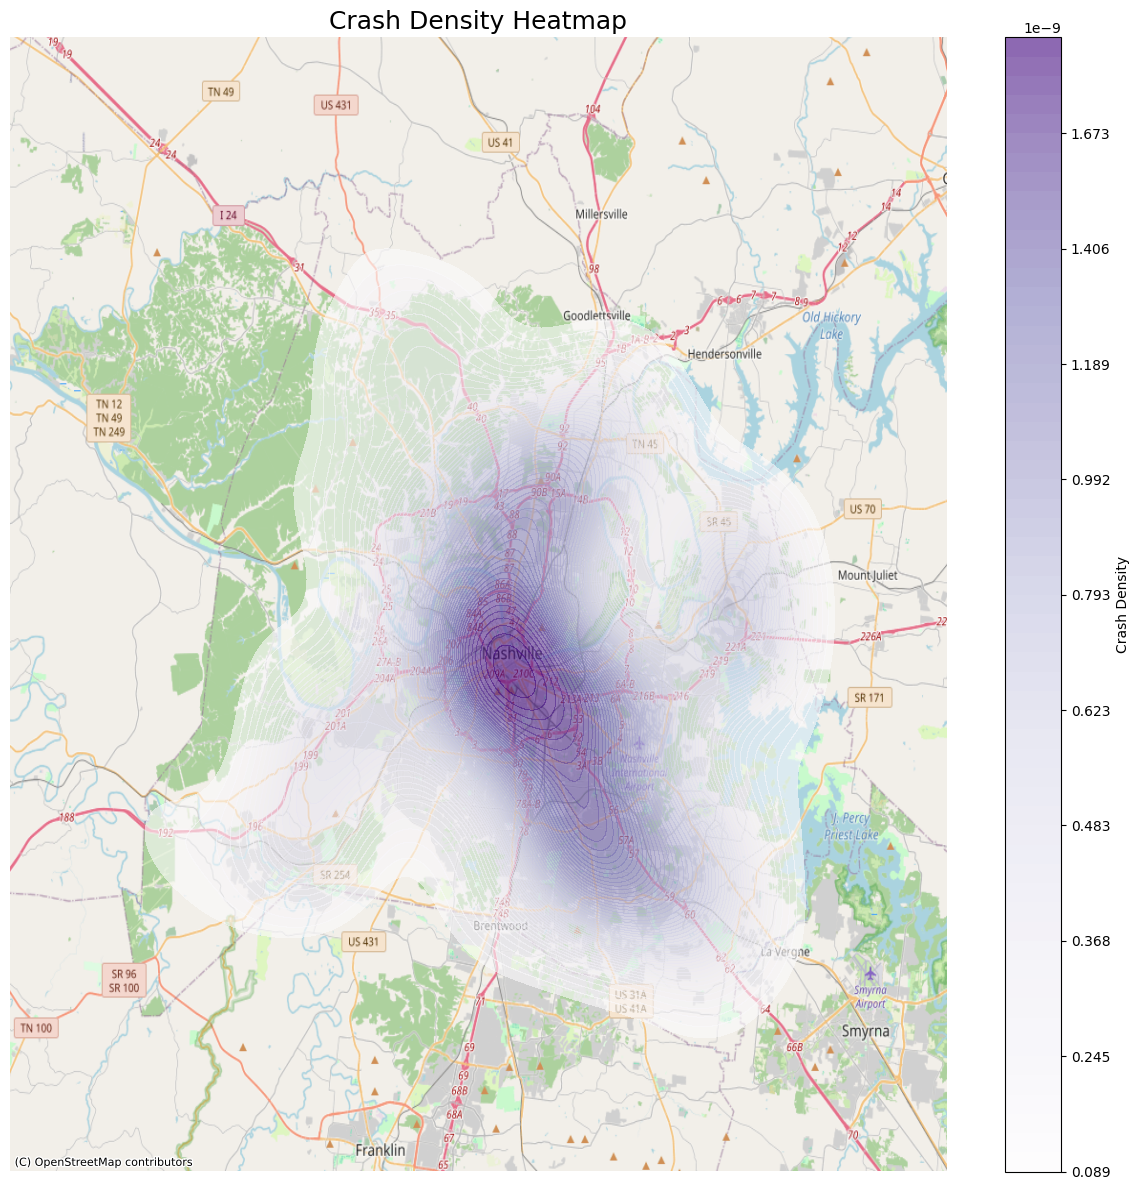

In [10]:
# create a GeoDataFrame from the crash data
gdf = gpd.GeoDataFrame(
    crash_df,
    geometry=gpd.points_from_xy(crash_df.lng, crash_df.lat),
    crs="EPSG:4326")

# reproject the data to Web Mercator (EPSG:3857), required to work with OpenStreetMap
gdf_web_mercator = gdf.to_crs(epsg=3857)

# extract x and y coordinates
x = gdf_web_mercator.geometry.x
y = gdf_web_mercator.geometry.y

# create figure and axis
fig, ax = plt.subplots(figsize=(12, 12))

#create heatmap
kde = sns.kdeplot(
    data=gdf_web_mercator,
    x=gdf_web_mercator.geometry.x,
    y=gdf_web_mercator.geometry.y,
    fill=True,
    cmap="Purples",
    levels=60,
    alpha=0.6,
    cbar=True,
    ax=ax
)

# format appropriately
cbar = kde.collections[0].colorbar
cbar.set_label("Crash Density")
cbar.formatter.set_powerlimits((0,0))
cbar.update_ticks()

# add base map
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Crash Density Heatmap", fontsize=18)
plt.tight_layout()
plt.savefig('../results/Crash_Density_Heatmap.png', bbox_inches='tight', facecolor='white')
plt.show()